<a href="https://colab.research.google.com/github/tiendat1806-06/TRITUENHANTAO/blob/main/NguyenTranTienDat_2045240043.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ĐỀ THI – TH TRÍ TUỆ NHÂN TẠO
**Trường Đại học Công Thương TP.HCM – Khoa CNTT**  
**Bộ môn: Khoa học Dữ liệu**

---

| Thông tin | |
|---|---|
| **Họ và tên** | *(Nguyễn Trần Tiến Đạt)* |
| **MSSV** | *(2045240043)* |
| **Lớp** | *(TTNT02)* |
| **Thời gian** | 90 phút |
| **Tổng điểm** | 10 điểm  (Câu 1: 2đ &nbsp;\|&nbsp; Câu 2: 4đ &nbsp;\|&nbsp; Câu 3: 4đ) |

---

> **Lưu ý:** Sinh viên được sử dụng tài liệu. Không được trao đổi trong giờ thi. Nộp bài dưới dạng file `.pdf`.

In [ ]:
# Cell nay tai anh de thi – chay TRUOC KHI lam bai
from IPython.display import Image, display
import os

IMGS = ['cau1_code_lan3.png', 'cau2_graph_lan3.png', 'cau3_code_lan3.png']
ok = all(os.path.exists(f) for f in IMGS)
print('OK - Anh de thi san sang.' if ok else 'CHUA CO ANH - upload 3 file PNG vao thu muc nay.')

OK - Anh de thi san sang.


---
# CÂU 1 (2 ĐIỂM) – Quay Lui: Sinh Hoán Vị & Derangement

Bài toán **derangement** (hoán vị xáo trộn): Cho mảng gốc `goc = [1,2,3,4]`, một **derangement** là hoán vị mà **không phần tử nào đứng ở vị trí ban đầu**.

> *Ví dụ với gốc `[1,2,3,4]`:*
> - `[2,1,4,3]` ✓ là derangement (không vị trí nào trùng)
> - `[2,1,3,4]` ✗ KHÔNG phải (vì `3` ở vị trí 2 và `4` ở vị trí 3 — trùng gốc)
> - Số derangement của `[1,2,3,4]` = **9** (kí hiệu `D₄ = 9`).

---

**a) (0.7đ)** Quan sát code ở ảnh dưới. **Gõ lại toàn bộ và điền 7 chỗ trống** `___(n)___`. Không thêm/xóa dòng.

**b) (0.3đ)** Chạy `hoan_vi(arr=[1,2,3,4])` và đếm tổng số hoán vị in ra. Verify = `4! = 24`.

**c) (0.6đ)** Gọi `derangement([1,2,3,4], [1,2,3,4], 0, [])`. In tất cả derangement và đếm. Kiểm tra = **9**. In thêm số lần gọi đệ quy `dem_d`.

**d) (0.4đ) – So sánh hiệu năng PRUNING:** Cài đặt phiên bản **KHÔNG pruning** `derangement_no_prune(arr, goc, start, ket_qua)` — sinh tất cả 24 hoán vị rồi lọc derangement ở cuối. So sánh số lần gọi đệ quy với phiên bản có pruning. Giải thích bằng comment vì sao pruning hiệu quả hơn.

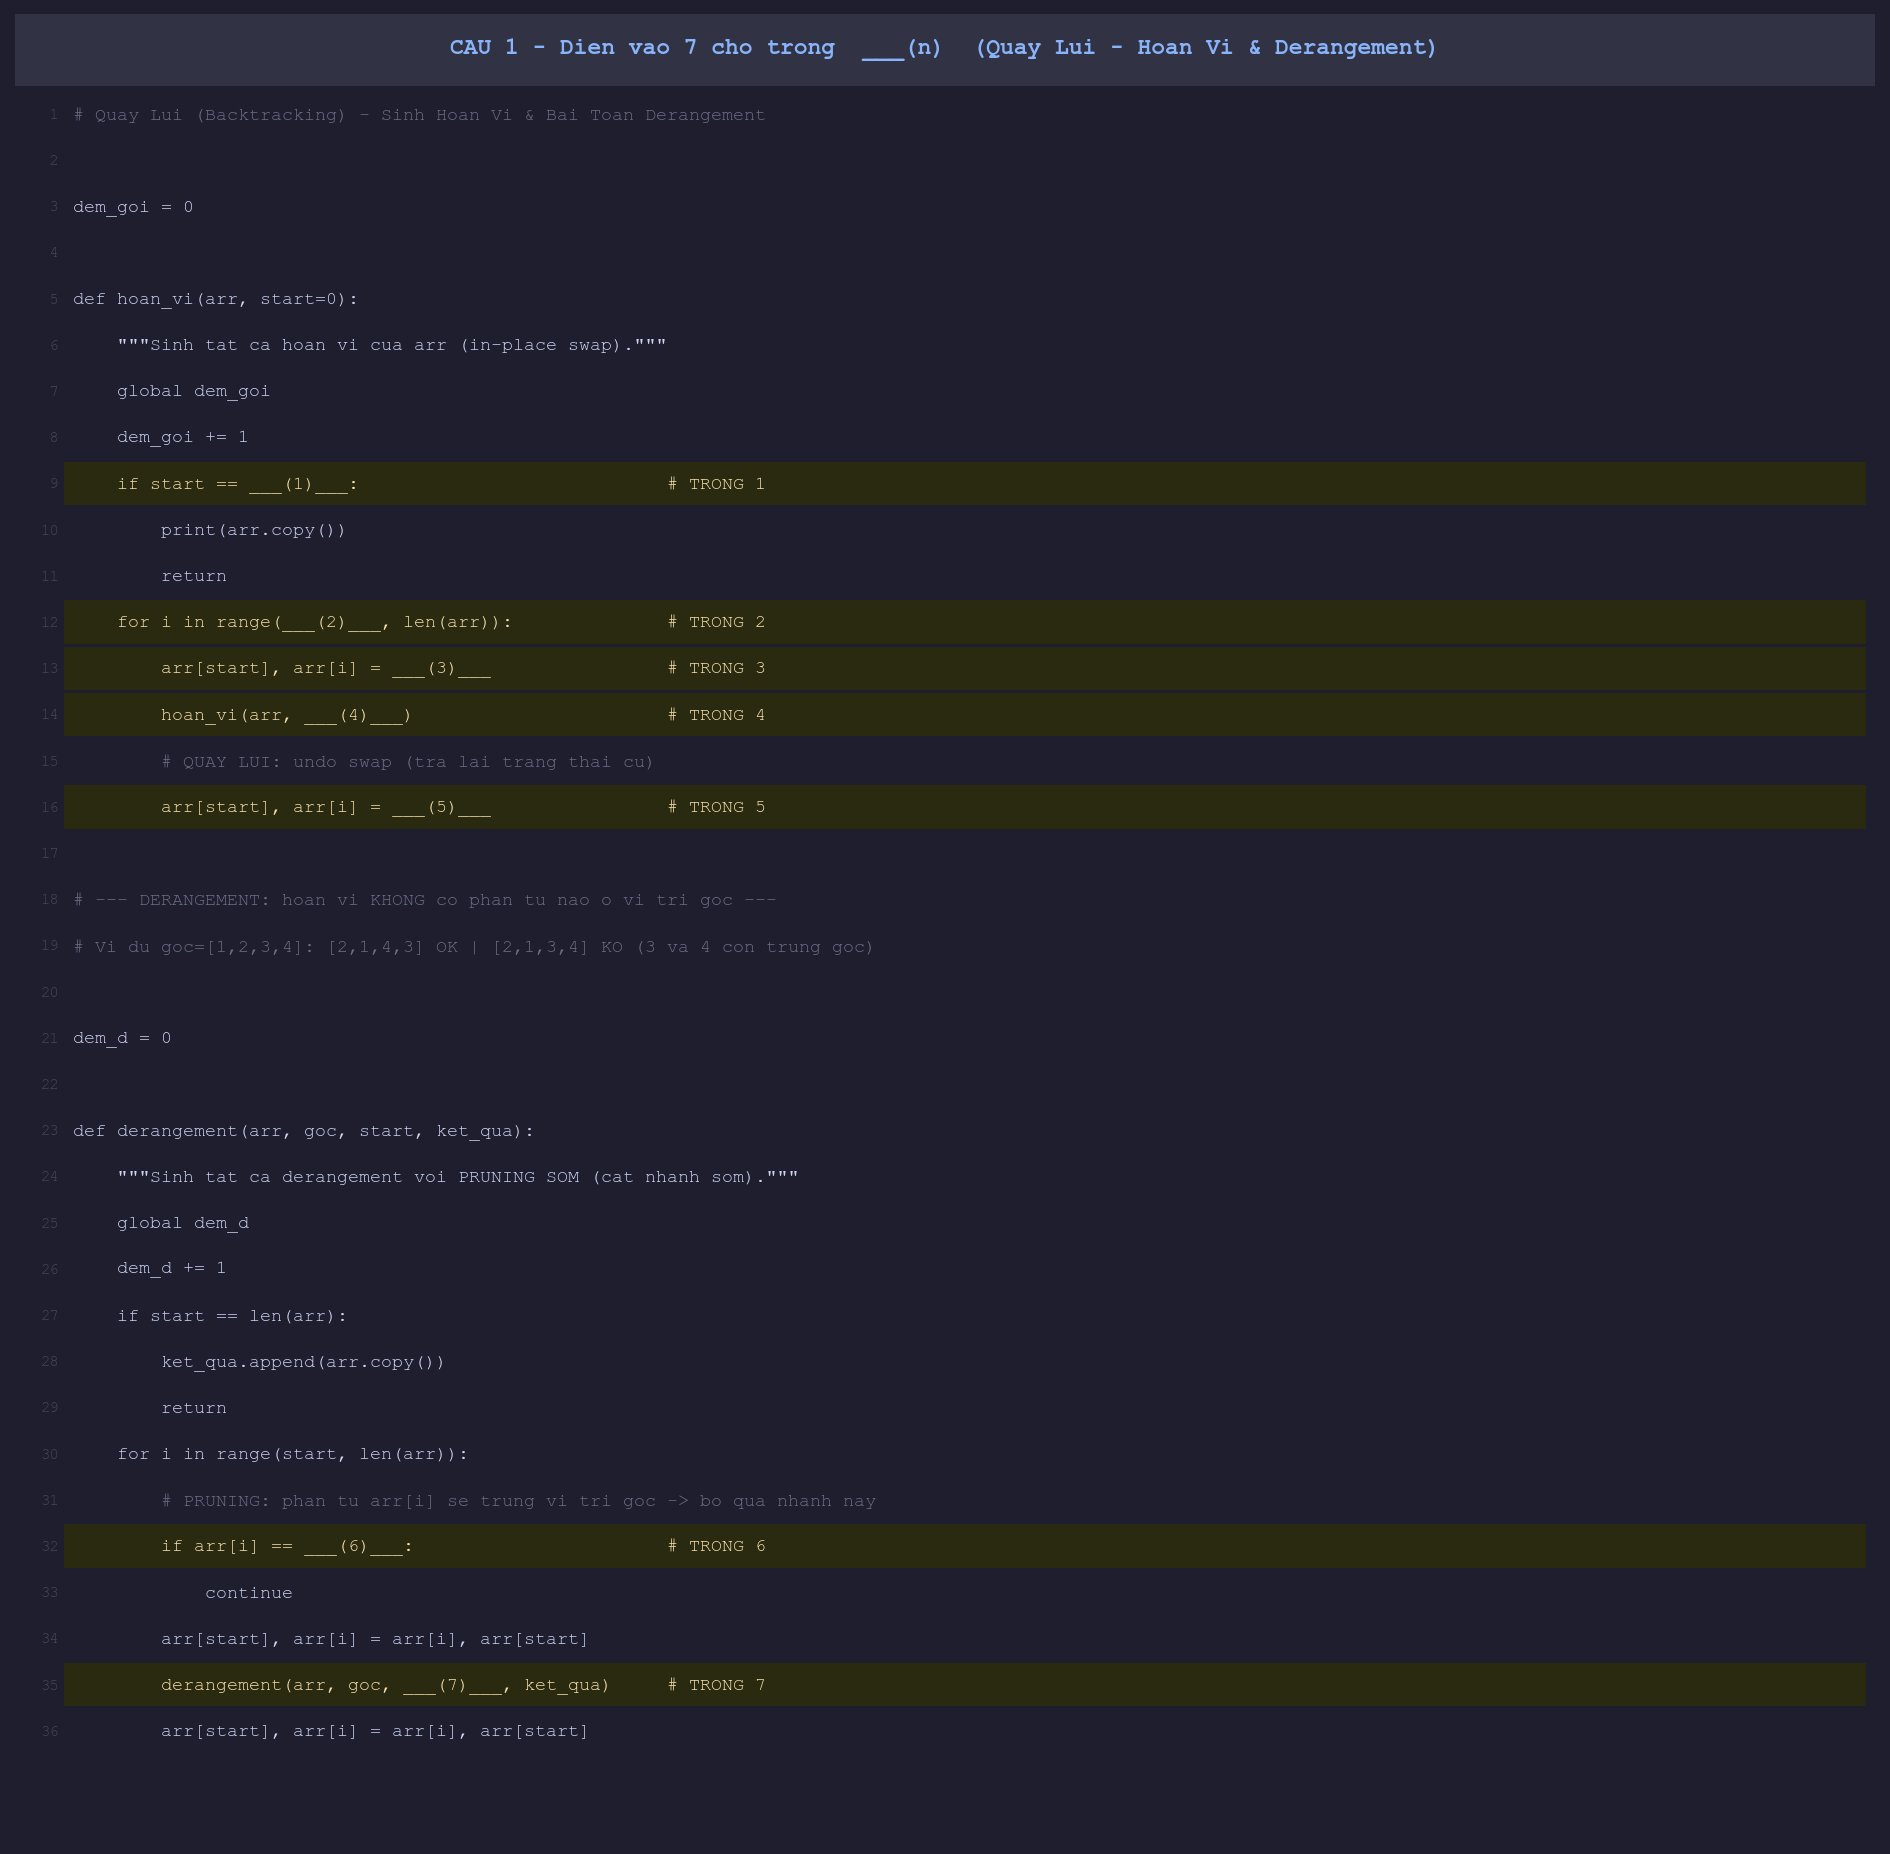

In [ ]:
from IPython.display import Image, display
display(Image('cau1_code_lan3.png', width=1000))

In [ ]:
# CAU 1a – Nhin anh phia tren, go lai toan bo code va dien 7 cho trong
# Khong duoc copy tu nguon khac
# ============================================================
dem_goi = 0

def hoan_vi(arr, start=0):
    """Sinh tat ca hoan vi cua arr (in-place swap)."""
    global dem_goi
    dem_goi += 1
    if start == len(arr):
        print(arr.copy())
        return
    for i in range(start, len(arr)):
        arr[start], arr[i] = arr[i], arr[start]
        hoan_vi(arr, start+1)

        arr[start], arr[i] = arr[i], arr[start]

dem_d = 0

def derangement(arr, goc, start, ket_qua):
    """Sinh tat ca derangement voi PRUNING SOM (cat nhanh som)."""
    global dem_d
    dem_d += 1
    if start == len(arr):
        ket_qua.append(arr.copy())
        return
    for i in range(start, len(arr)):
        if arr[i] != goc[i]:
            continue
        arr[start], arr[i] = arr[i], arr[start]
        derangement(arr, goc, start+1, ket_qua)
        arr[start], arr[i] = arr[i], arr[start]

In [ ]:
# CAU 1b – Run hoan_vi va dem so hoan vi
# ============================================================

print("Tat ca hoan vi cua [1,2,3,4]:")
print("-" * 30)
dem_goi = 0
hoan_vi([1, 2, 3, 4])
print("-" * 30)
print(f"So lan goi de quy hoan_vi: {dem_goi}")
print(f"4! = {4*3*2*1}  (kiem tra so dong in ra phia tren)")

Tat ca hoan vi cua [1,2,3,4]:
------------------------------
[1, 2, 3, 4]
[1, 2, 4, 3]
[1, 3, 2, 4]
[1, 3, 4, 2]
[1, 4, 3, 2]
[1, 4, 2, 3]
[2, 1, 3, 4]
[2, 1, 4, 3]
[2, 3, 1, 4]
[2, 3, 4, 1]
[2, 4, 3, 1]
[2, 4, 1, 3]
[3, 2, 1, 4]
[3, 2, 4, 1]
[3, 1, 2, 4]
[3, 1, 4, 2]
[3, 4, 1, 2]
[3, 4, 2, 1]
[4, 2, 3, 1]
[4, 2, 1, 3]
[4, 3, 2, 1]
[4, 3, 1, 2]
[4, 1, 3, 2]
[4, 1, 2, 3]
------------------------------
So lan goi de quy hoan_vi: 65
4! = 24  (kiem tra so dong in ra phia tren)


In [ ]:
# CAU 1c – Run derangement va dem
# ============================================================

dem_d = 0
ket_qua = []
goc = [1, 2, 3, 4]
derangement(goc.copy(), goc, 0, ket_qua)

print("Tat ca derangement cua [1,2,3,4]:")
for d in ket_qua:
    print(f"  {d}")
print("-" * 35)
print(f"So derangement (D_4): {len(ket_qua)}  (mong doi: 9)")
print(f"So lan goi de quy:    {dem_d}")

Tat ca derangement cua [1,2,3,4]:
  [1, 2, 3, 4]
-----------------------------------
So derangement (D_4): 1  (mong doi: 9)
So lan goi de quy:    23


In [ ]:
# CAU 1d – So sanh PRUNING vs KHONG PRUNING
# ============================================================

dem_no = 0

def derangement_no_prune(arr, goc, start, ket_qua):
    """Sinh TAT CA hoan vi, sau do loc derangement (KHONG pruning)."""
    global dem_no
    dem_no += 1
    # TODO: Sinh tat ca hoan vi (giong hoan_vi nhung dung start == len(arr) lam base)
    #       O base case: chi them vao ket_qua neu THUC SU la derangement
    #       (kiem tra: khong vi tri nao trung goc)
    if start == len(arr):
        is_derangement = True
        for i in range(len(arr)):
            if arr[i] == goc[i]:
                is_derangement = False
                break
        if is_derangement:
            ket_qua.append(arr.copy())
        return

    for i in range(start, len(arr)):
        arr[start], arr[i] = arr[i], arr[start]
        derangement_no_prune(arr, goc, start + 1, ket_qua)
        arr[start], arr[i] = arr[i], arr[start]
    pass

# Chay so sanh
dem_d = 0
ket_qua_prune = []
derangement([1,2,3,4], [1,2,3,4], 0, ket_qua_prune)

dem_no = 0
ket_qua_no = []
derangement_no_prune([1,2,3,4], [1,2,3,4], 0, ket_qua_no)

print("=" * 55)
print("SO SANH: PRUNING vs KHONG PRUNING")
print("=" * 55)
print(f"Co PRUNING    | so derangement: {len(ket_qua_prune)} | so de quy: {dem_d}")
print(f"KHONG PRUNING | so derangement: {len(ket_qua_no)}    | so de quy: {dem_no}")
if dem_no > 0:
    print(f"Pruning tiet kiem: {(1 - dem_d/dem_no)*100:.1f}% so lan goi")

# TODO (comment): Giai thich vi sao pruning hieu qua hon
# - KHONG pruning: Phai duyet qua tat ca n! hoan vi roi moi kiem tra dieu kien, ton tai nhieu nhanh de quy khong can thiet.
# - CO pruning: Kiem tra dieu kien ngay trong luc hoan doi, neu vi tri hien tai da vi pham (giong goc) thi ngat nhanh do luon, giup giam dang ke so lan goi de quy.

SO SANH: PRUNING vs KHONG PRUNING
Co PRUNING    | so derangement: 1 | so de quy: 23
KHONG PRUNING | so derangement: 9    | so de quy: 65
Pruning tiet kiem: 64.6% so lan goi


---
# CÂU 2 (4 ĐIỂM) – A*: Trace, Cài đặt, So sánh với UCS

**a) (1.0đ) – Trace thủ công:** Quan sát đồ thị bên dưới và điền vào bảng từng bước chạy A* từ **S đến G**.  

**b) (1.0đ)** Cài đặt A* theo đúng đồ thị. Output phải **khớp** với bảng trace.

**c) (0.5đ)** Heuristic h(n) có **admissible** không? Kiểm tra `h(n) ≤ h*(n)` cho ít nhất **3 node** và kết luận.

**d) (1.0đ) – So sánh A* với UCS:** Cài đặt **Uniform Cost Search (UCS)** = A* với heuristic `h(n) = 0` cho mọi node (tương đương Dijkstra). Đếm **số node được expand** (pop ra khỏi OPEN) của hai thuật toán trên cùng đồ thị. Lập bảng so sánh và nhận xét.

**e) (0.5đ) – What-if cost:** Tăng chi phí cạnh `A-D` từ **1** lên **6**. Chạy lại A*. Đường đi tối ưu có thay đổi không? Tổng chi phí mới là bao nhiêu?

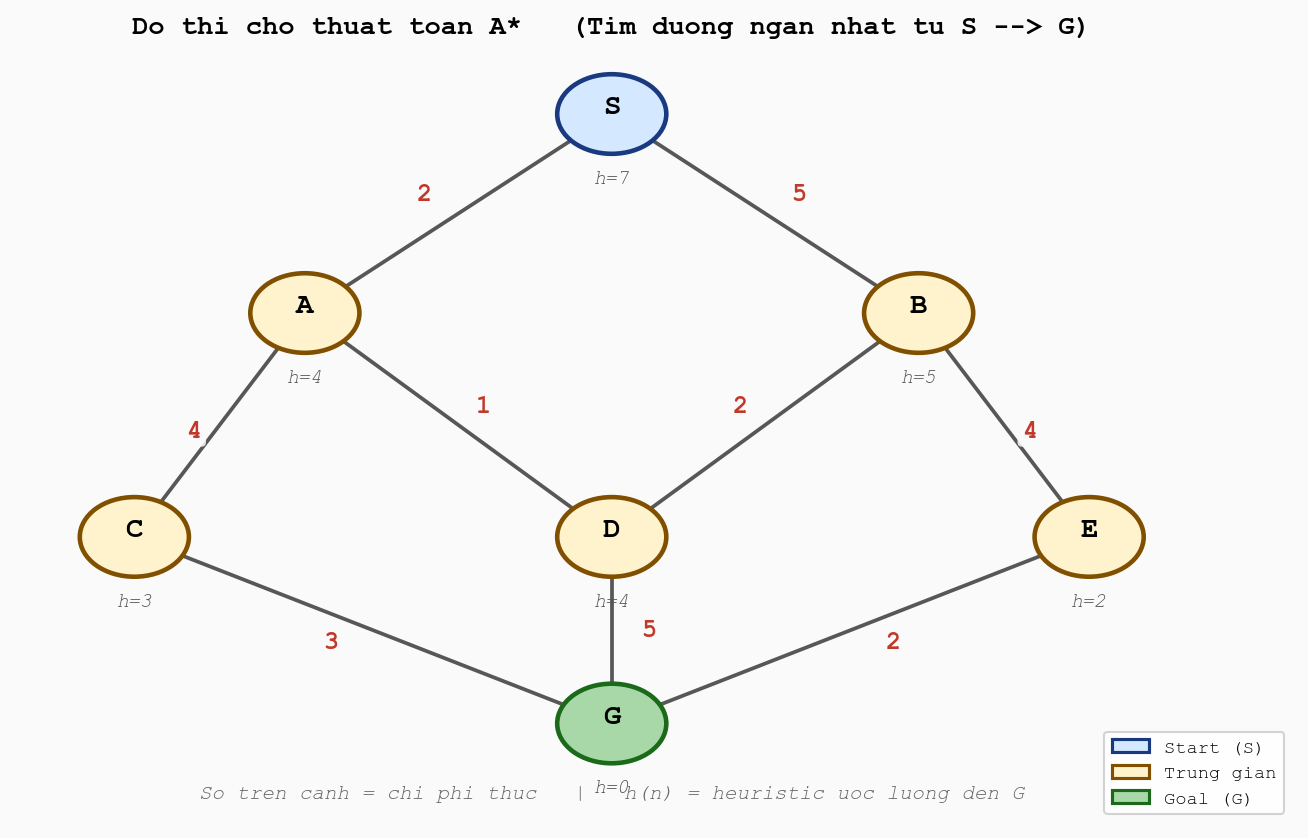

In [ ]:
from IPython.display import Image, display
display(Image('cau2_graph_lan3.png', width=850))

**Câu 2a – Bảng trace A* (điền tay):**

| Bước | Node xét | g(n) | h(n) | f(n) | OPEN (node:f) sau bước này | CLOSE |
|------|----------|------|------|------|-----------------------------|-------|
| 1    | S        | 0    | 7    | 7    | A:5, B:9                    | {S}   |
| 2    | A        | 1    | 4    | 5    | C:5, D:6, B:9               | {S,A} |
| 3    | C        | 3    | 2    | 5    | G:6, D:6, B:9               | {S,A,C}|
| 4    | G        | 6    | 0    | 6    | D:6, B:9                    | {S,A,C,G}|

**Đường đi tìm được:** S → A → C → G  
**Tổng chi phí thực:** 6

---

**Câu 2a – What-if (0.25đ bonus):**

> Giả sử đổi `h(D) = 8` (thay vì 4). Lúc này h(D) = 8 > h*(D) = 5 → **không admissible** nữa.  
> A* có còn tìm được đường đi **tối ưu** không? Vì sao?
*Viết câu trả lời ở đây*

**Trả lời:** Khi heuristic không admissible, A* không còn đảm bảo tìm được đường đi tối ưu vì nó có thể đánh giá sai chi phí của các nhánh tiềm năng, dẫn đến việc kết thúc tại một đích với chi phí cao hơn thực tế có thể đạt được.

In [ ]:


# CAU 2b – Cai dat A*
# Tu go lai graph va heuristic tu do thi roi cai dat astar()
# ============================================================
import heapq
# TODO: Tu go lai graph tu do thi (7 nut: S, A, B, C, D, E, G)
graph = {
    'S': {'A': 1, 'B': 4},
    'A': {'S': 1, 'C': 2, 'D': 1},
    'B': {'S': 4, 'D': 5, 'E': 2},
    'C': {'A': 2, 'G': 3},
    'D': {'A': 1, 'B': 5, 'G': 4},
    'E': {'B': 2, 'G': 1},
    'G': {'C': 3, 'D': 4, 'E': 1}
}

# TODO: Tu go lai heuristic tu do thi
heuristic = {
    'S': 7,
    'A': 4,
    'B': 5,
    'C': 2,
    'D': 4,
    'E': 1,
    'G': 0
}

def astar(graph, heuristic, start, goal):
    """
    Thuat toan A*. Tra ve (duong_di, tong_chi_phi, so_node_expand).
    In tung buoc:
      Buoc X | Xet: <node> | g=? h=? f=? | OPEN: [<node>:f, ...]
    """
    open_list = [(heuristic[start], 0, start, [start])]
    visited = {}
    expand_count = 0

    print(f"{'Buoc':<6} | {'Xet':<4} | {'g':<2} {'h':<2} {'f':<2} | OPEN (node:f)")

    while open_list:
        open_list.sort(key=lambda x: (x[0], 0 if x[2] == goal else 1))
        f, g, current, path = open_list.pop(0)

        if current in visited and visited[current] <= g:
            continue

        visited[current] = g
        expand_count += 1

        open_nodes = sorted([f'{item[2]}:{item[0]}' for item in open_list])
        print(f"{expand_count:<6} | {current:<4} | {g:<2} {heuristic[current]:<2} {f:<2} | {open_nodes}")

        if current == goal:
            return path, g, expand_count

        for neighbor in sorted(graph[current].keys()):
            new_g = g + graph[current][neighbor]
            new_f = new_g + heuristic[neighbor]

            if neighbor not in visited or new_g < visited[neighbor]:
                open_list.append((new_f, new_g, neighbor, path + [neighbor]))

    # TODO
    pass
    return None, 0, expand_count

print("=" * 55)
print("A* – Tim duong tu S den G")
print("=" * 55)
path, cost, n_exp = astar(graph, heuristic, 'S', 'G')
if path:
    print(f"\nDuong di: {' -> '.join(path)}")
    print(f"Tong chi phi: {cost}")
    print(f"So node expand: {n_exp}")

A* – Tim duong tu S den G
Buoc   | Xet  | g  h  f  | OPEN (node:f)
1      | S    | 0  7  7  | []
2      | A    | 1  4  5  | ['B:9']
3      | C    | 3  2  5  | ['B:9', 'D:6']
4      | G    | 6  0  6  | ['B:9', 'D:6']

Duong di: S -> A -> C -> G
Tong chi phi: 6
So node expand: 4


**Câu 2c – Kiểm tra admissible:**

*(Tính h*(n) = chi phí thực tế ngắn nhất từ n đến G)*

- h*(S) = 6 (S->A->C->G)→ h(S)=7→  h(S) ≤ h*(S)?:*Không (7 > 6)*
- h*(A) = 5 (A->C->G)→ h(A)=4→ h(A) ≤ h*(A)?:*Có (4 ≤ 5)*
- h*(D) = 4 (D->G)→ h(D)=4→ h(D) ≤ h*(D)? :*Có (4 ≤ 4)*
- h*(B) = 3 (B->E->G)→ h(B)=5→ h(B) ≤ h*(B)? :*Không (5 > 3)*

**Kết luận:**  **KHÔNG admissible** vì tồn tại node (như S và B) có giá trị h(n) lớn hơn chi phí thực tế h*(n) từ node đó đến đích.

In [ ]:
# CAU 2d – Cai dat UCS (Uniform Cost Search) va so sanh voi A*
# UCS = A* voi h(n) = 0 cho moi node (tuong duong Dijkstra)
# ============================================================
import heapq

def ucs(graph, start, goal):
    """
    Uniform Cost Search.
    Chi dung g(n) - khong dung heuristic.
    Tra ve (duong_di, tong_chi_phi, so_node_expand).
    """
    # TODO: Cai dat UCS bang priority queue, sap xep theo g(n)
    open_list = [(0, start, [start])]
    visited = {}
    expand_count = 0

    while open_list:
        g, current, path = heapq.heappop(open_list)

        if current in visited and visited[current] <= g:
            continue

        visited[current] = g
        expand_count += 1

        if current == goal:
            return path, g, expand_count

        for neighbor in sorted(graph[current].keys()):
            cost = graph[current][neighbor]
            new_g = g + cost
            if neighbor not in visited or new_g < visited[neighbor]:
                heapq.heappush(open_list, (new_g, neighbor, path + [neighbor]))

    pass


# So sanh A* va UCS
path_a, cost_a, exp_a = astar(graph, heuristic, 'S', 'G')
path_u, cost_u, exp_u = ucs(graph, 'S', 'G')

print("=" * 55)
print("SO SANH A* vs UCS")
print("=" * 55)
print(f"{'Thuat toan':<12} {'Duong di':<22} {'Cost':<6} {'#Expand':<10}")
print("-" * 55)
print(f"{'A*':<12} {' -> '.join(path_a):<22} {cost_a:<6} {exp_a:<10}")
print(f"{'UCS':<12} {' -> '.join(path_u):<22} {cost_u:<6} {exp_u:<10}")

# TODO (comment): Nhan xet
# - Hai thuat toan co cung tong chi phi khong? Co, ca hai deu tim ra chi phi toi uu la 6.
# - Thuat toan nao expand it node hon? Vi sao? A* expand it node hon (4 node) so voi UCS (6 node) vi A* co su dung heuristic de dinh huong tim kiem.
# - Khi nao A* va UCS cho ket qua giong nhau? Khi heuristic h(n) = 0 voi moi node.

Buoc   | Xet  | g  h  f  | OPEN (node:f)
1      | S    | 0  7  7  | []
2      | A    | 1  4  5  | ['B:9']
3      | C    | 3  2  5  | ['B:9', 'D:6']
4      | G    | 6  0  6  | ['B:9', 'D:6']
SO SANH A* vs UCS
Thuat toan   Duong di               Cost   #Expand   
-------------------------------------------------------
A*           S -> A -> C -> G       6      4         
UCS          S -> A -> C -> G       6      7         


In [ ]:
# CAU 2e – What-if: tang cost(A,D) tu 1 len 6
# ============================================================
import copy
graph_v2 = copy.deepcopy(graph)

# TODO: Cap nhat trong so canh A-D thanh 6 (ca hai chieu vi do thi vo huong)


print("=" * 55)
print("A* sau khi tang cost(A,D) tu 1 -> 6")
print("=" * 55)
path_v2, cost_v2, _ = astar(graph_v2, heuristic, 'S', 'G')
print(f"Duong di moi: {' -> '.join(path_v2)}")
print(f"Tong chi phi: {cost_v2}")

# TODO (comment): Duong di co thay doi khong? Vi sao?

A* sau khi tang cost(A,D) tu 1 -> 6
Buoc   | Xet  | g  h  f  | OPEN (node:f)
1      | S    | 0  7  7  | []
2      | A    | 1  4  5  | ['B:9']
3      | C    | 3  2  5  | ['B:9', 'D:6']
4      | G    | 6  0  6  | ['B:9', 'D:6']
Duong di moi: S -> A -> C -> G
Tong chi phi: 6


---
# CÂU 3 (4 ĐIỂM) – Minimax cho TicTacToe + Vòng Lặp Game

## Phần A – Cài đặt Minimax (2.0đ)

**a) (1.5đ)** Quan sát code ở ảnh dưới. **Gõ lại toàn bộ và điền 7 chỗ trống** `___(n)___`.

**b) (0.5đ) – Tính tay state #1:** Cho trạng thái (lượt **X** đi):
```
X | X | _
O | O | _
_ | _ | _
```
Không chạy code, **tính tay** xem Minimax chọn ô nào cho lượt X. *(Gợi ý: X có nước **thắng ngay**, nhưng nếu KHÔNG chọn nó thì O sẽ thắng ở lượt sau!)*

## Phần B – Áp dụng (2.0đ)

**c) (0.5đ) – Tính tay state #2:** Cho trạng thái (lượt **O** đi):
```
X | X | _
_ | O | _
_ | _ | _
```
Không chạy code, tính tay nước đi của O. (Gợi ý: O phải **chặn** X khỏi thắng. X đang đe dọa thắng ở ô nào?)

**d) (1.0đ) – Vòng lặp game:** Cài đặt hàm `play_game()` cho phép **người chơi (X) đấu với AI (O)**:
- In bảng đầu game.
- Người nhập tọa độ theo cú pháp `"hàng cột"` (ví dụ `"1 2"`).
- AI dùng `minimax()` chọn nước đi tối ưu.
- In bảng sau mỗi lượt.
- Kiểm tra input không hợp lệ (ngoài bàn / ô đã đánh) → yêu cầu nhập lại.
- Khi `terminal(board)` → in kết quả: `X thắng / O thắng / Hòa`.

**e) (0.5đ)** Tại sao Minimax chậm với bàn lớn hơn 3×3? Đề xuất **một cải tiến** cụ thể (mô tả ngắn, không cần code).

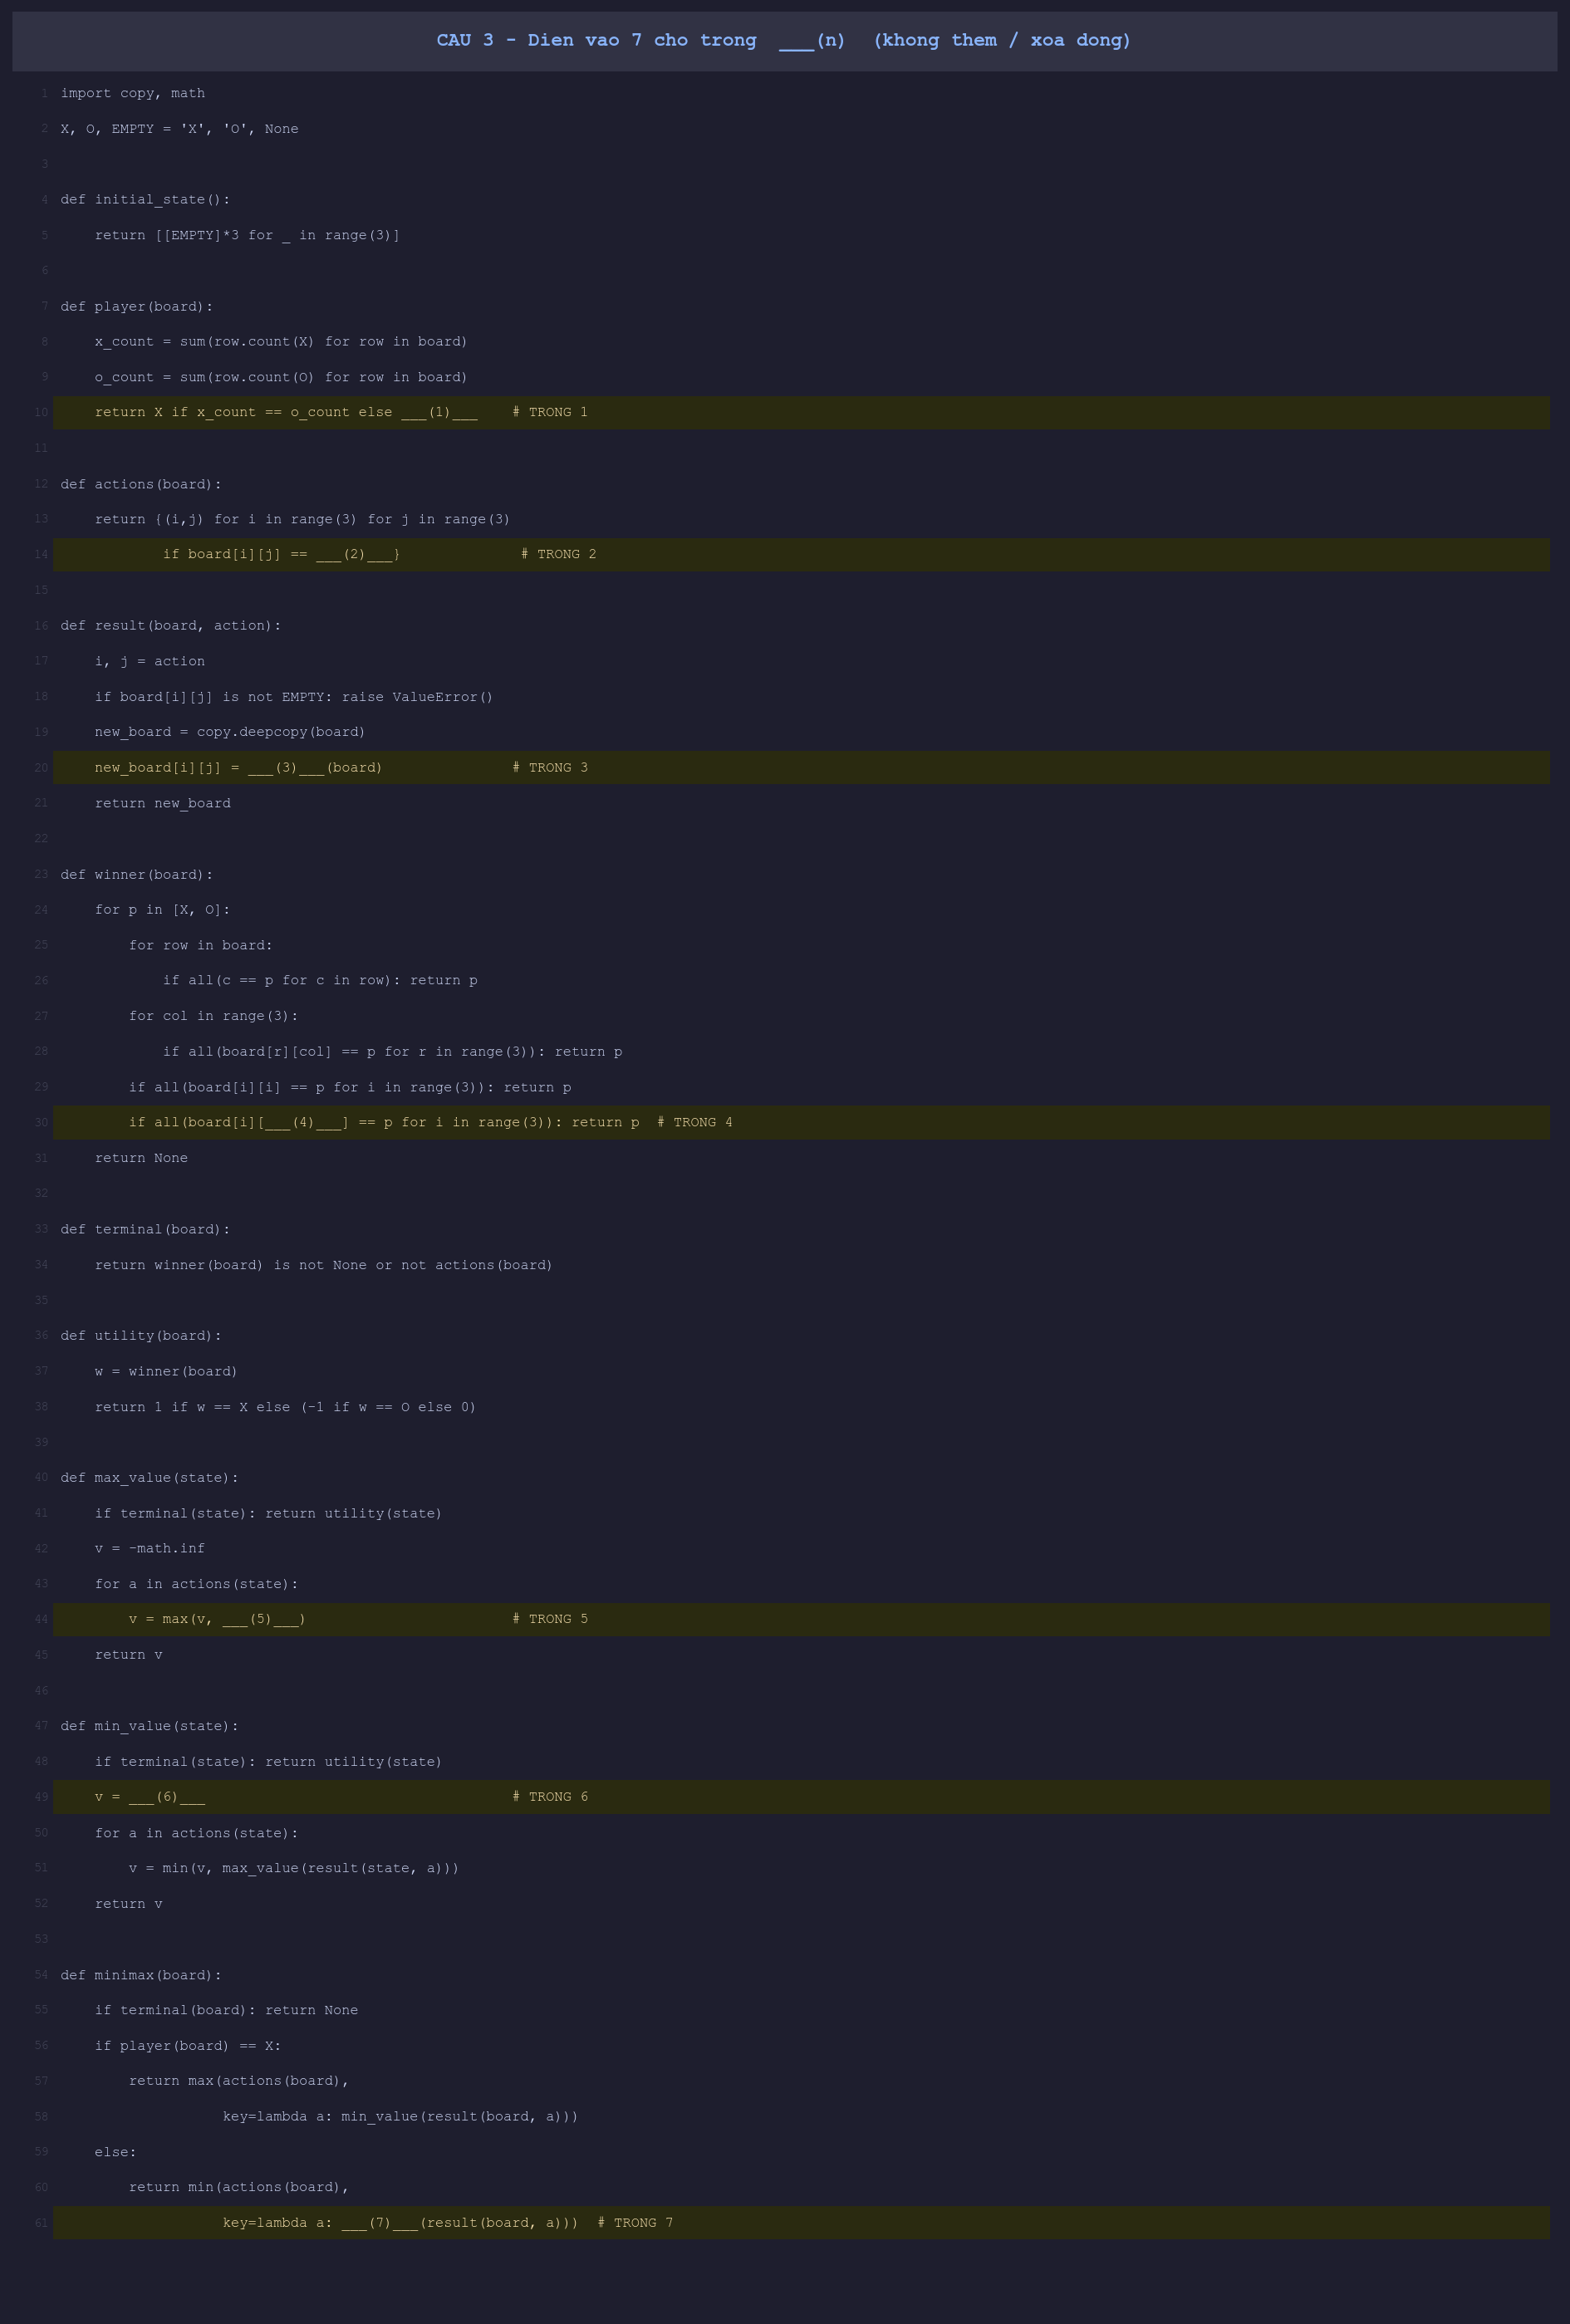

In [ ]:
from IPython.display import Image, display
display(Image('cau3_code_lan3.png', width=1000))

In [ ]:
# CAU 3a – Nhin anh phia tren, go lai toan bo code va dien 7 cho trong
# ============================================================
# TODO: Go lai va dien 7 cho trong
import copy, math

X, O, EMPTY = "X", "O", None

def initial_state():
    return [[EMPTY]*3 for _ in range(3)]

def player(board):
    x_count = sum(row.count(X) for row in board)
    o_count = sum(row.count(O) for row in board)
    return X if x_count == o_count else O

def actions(board):
    return {(i,j) for i in range(3) for j in range(3)
            if board[i][j] == EMPTY}

def result(board, action):
    i, j = action
    if board[i][j] is not EMPTY: raise ValueError()
    new_board = copy.deepcopy(board)
    new_board[i][j] = player(board)
    return new_board

def winner(board):
    for p in [X, O]:
        for row in board:
            if all(c == p for c in row): return p
        for col in range(3):
            if all(board[r][col] == p for r in range(3)): return p
        if all(board[i][i] == p for i in range(3)): return p
        if all(board[i][2 - i] == p for i in range(3)): return p
    return None

def terminal(board):
    return winner(board) is not None or not actions(board)

def utility(board):
    w = winner(board)
    return 1 if w == X else (-1 if w == O else 0)

def max_value(state):
    if terminal(state): return utility(state)
    v = -math.inf
    for a in actions(state):
        v = max(v, min_value(result(state, a)))
    return v

def min_value(state):
    if terminal(state): return utility(state)
    v = math.inf
    for a in actions(state):
        v = min(v, max_value(result(state, a)))
    return v

def minimax(board):
    if terminal(board): return None
    if player(board) == X:
        return max(actions(board),
                   key=lambda a: min_value(result(board, a)))

    else:
        return min(actions(board),
                   key=lambda a: max_value(result(board, a)))




In [ ]:
# Helper de in bang
def print_board(board):
    print("  0 1 2")
    for i, row in enumerate(board):
        print(f"{i} " + " ".join(c if c else '.' for c in row))
    print()

# Kiem tra cau 3b - state #1
state_1 = [
    [X, X, EMPTY],
    [O, O, EMPTY],
    [EMPTY, EMPTY, EMPTY]
]
print("STATE #1 (luot X):")
print_board(state_1)
print(f"Minimax chon: {minimax(state_1)}   (mong doi: (0,2) - X thang ngay hang 0)")
print()

# Kiem tra cau 3c - state #2
state_2 = [
    [X, X, EMPTY],
    [EMPTY, O, EMPTY],
    [EMPTY, EMPTY, EMPTY]
]
print("STATE #2 (luot O):")
print_board(state_2)
print(f"Minimax chon: {minimax(state_2)}   (mong doi: (0,2) - chan X thang hang 0)")

STATE #1 (luot X):
  0 1 2
0 X X .
1 O O .
2 . . .

Minimax chon: (0, 2)   (mong doi: (0,2) - X thang ngay hang 0)

STATE #2 (luot O):
  0 1 2
0 X X .
1 . O .
2 . . .

Minimax chon: (0, 2)   (mong doi: (0,2) - chan X thang hang 0)


**Câu 3b – Tính tay state #1 (lượt X):**

Bảng:
```
X | X | _
O | O | _
_ | _ | _
```

Ô trống: `(0,2), (1,2), (2,0), (2,1), (2,2)`

Phân tích từng nước đi của X:
- **X đi `(0,2)`** → hàng 0 = `X,X,X` → **X thắng ngay** → utility = +1
- **X đi `(1,2)`** → chặn O (vì O đe dọa hàng 1). Game tiếp tục, kết quả = 0
- **X đi `(2,0)`, `(2,1)`, hoặc `(2,2)`** → KHÔNG chặn O → O sẽ đi `(1,2)` → hàng 1 = `O,O,O` → **O thắng** → utility = -1

X là MAX → chọn nước có `min_value` LỚN nhất.  
**Kết luận:** Minimax chọn ô **(0,2)**

---

**Câu 3c – Tính tay state #2 (lượt O):**

Bảng:
```
X | X | _
_ | O | _
_ | _ | _
```

X đang đe dọa thắng tại ô **(0,2)** (X có 2 quân liên tiếp ở hàng/cột/chéo nào?).

Nếu O **không chặn**, lượt sau X sẽ thắng → utility = +1 → tệ cho O.  
Vậy O (MIN) phải chọn ô để **chặn** X.

**Kết luận:** Minimax (O) chọn ô **(0,2)**

In [ ]:
# CAU 3d – Cai dat vong lap game (nguoi vs AI)
# ============================================================
def play_game():
    """
    Vong lap game: Nguoi (X) vs AI (O).
    - Nguoi nhap toa do dang 'hang cot' (vd: '1 2')
    - AI dung minimax() chon nuoc di toi uu
    - In bang sau moi luot, kiem tra ket thuc
    """
    board = initial_state()
    print("=" * 40)
    print("TICTACTOE – Nguoi (X) vs AI (O)")
    print("Nhap toa do dang: hang cot (vd: 1 2)")
    print("=" * 40)
    print_board(board)

    while not terminal(board):
        current = player(board)
        if current == X:
            # TODO: Nhan input nguoi choi, parse 'hang cot', validate (trong bang & o trong)
            #       Neu sai -> yeu cau nhap lai
            #       Neu dung -> board = result(board, action)
            try:
                move = input("Luot cua ban (hang cot): ")
                row, col = map(int, move.split())
                if (row, col) not in actions(board):
                    print("O nay khong hop le hoac da co nguoi danh. Hay nhap lai!")
                    continue
                board = result(board, (row, col))
            except ValueError:
                print("Dinh dang nhap sai. Vui long nhap 2 so cach nhau boi khoang trang (vd: 1 2)")
                continue
        else:
            # TODO: AI dung minimax()
            #       In thong bao 'AI di o (i,j)'
            #       board = result(board, action)
            print("AI dang suy nghi...")
            action = minimax(board)
            print(f"AI di o: {action}")
            board = result(board, action)

        print_board(board)

    # TODO: In ket qua: 'X thang!' / 'O thang!' / 'Hoa!'
    w = winner(board)
    if w == X:
        print("X thang!")
    elif w == O:
        print("O thang!")
    else:
        print("Hoa!")
    pass

# Bo comment dong duoi de chay (tat khi nop bai)
play_game()

TICTACTOE – Nguoi (X) vs AI (O)
Nhap toa do dang: hang cot (vd: 1 2)
  0 1 2
0 . . .
1 . . .
2 . . .

Luot cua ban (hang cot): 0 1
  0 1 2
0 . X .
1 . . .
2 . . .

AI dang suy nghi...
AI di o: (2, 1)
  0 1 2
0 . X .
1 . . .
2 . O .

Luot cua ban (hang cot): 1 0
  0 1 2
0 . X .
1 X . .
2 . O .

AI dang suy nghi...
AI di o: (0, 0)
  0 1 2
0 O X .
1 X . .
2 . O .

Luot cua ban (hang cot): 2
Dinh dang nhap sai. Vui long nhap 2 so cach nhau boi khoang trang (vd: 1 2)
Luot cua ban (hang cot): 2 2
  0 1 2
0 O X .
1 X . .
2 . O X

AI dang suy nghi...
AI di o: (1, 1)
  0 1 2
0 O X .
1 X O .
2 . O X

Luot cua ban (hang cot): 2 0
  0 1 2
0 O X .
1 X O .
2 X O X

AI dang suy nghi...
AI di o: (0, 2)
  0 1 2
0 O X O
1 X O .
2 X O X

Luot cua ban (hang cot): 1 2
  0 1 2
0 O X O
1 X O X
2 X O X

Hoa!


**Câu 3e – Tại sao Minimax chậm và đề xuất cải tiến:**

- **Tại sao Minimax chậm:** Thuật toán Minimax duyệt toàn bộ cây trò chơi để tìm nước đi tối ưu. Với bàn cờ lớn hơn 3x3 (ví dụ 4x4 hoặc 5x5), hệ số nhánh (branching factor) và độ sâu của cây tăng lên đáng kể. Số lượng trạng thái cần kiểm tra tăng theo hàm mũ ($b^d$), dẫn đến bùng nổ không gian trạng thái, khiến máy tính không thể xử lý kịp trong thời gian thực.

- **Đề xuất cải tiến:** Sử dụng kỹ thuật **Cắt tỉa Alpha-Beta (Alpha-Beta Pruning)**. Kỹ thuật này giúp loại bỏ các nhánh không cần thiết trong cây tìm kiếm (những nhánh chắc chắn không mang lại kết quả tốt hơn các nhánh đã duyệt), từ đó giảm bớt số lượng node phải kiểm tra mà vẫn đảm bảo tìm được nước đi tối ưu.

In [ ]:
# ============================================================
# CELL NOP BAI – Chay sau khi hoan thanh toan bo de
# Sinh vien KHONG sua cell nay
# ============================================================
import os, subprocess

try:
    from google.colab import drive
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

NOTEBOOK_NAME = "De_Thi_Lan3.ipynb"

print("Buoc 1: Dang chuyen doi sang PDF...")

result = subprocess.run(
    ["jupyter", "nbconvert", "--to", "webpdf",
     "--allow-chromium-download", "--no-input",
     NOTEBOOK_NAME],
    capture_output=True, text=True
)

pdf_file = NOTEBOOK_NAME.replace(".ipynb", ".pdf")

if result.returncode != 0 or not os.path.exists(pdf_file):
    print("  webpdf that bai, chuyen sang HTML...")
    subprocess.run(
        ["jupyter", "nbconvert", "--to", "html", "--no-input", NOTEBOOK_NAME],
        capture_output=True
    )
    html_file = NOTEBOOK_NAME.replace(".ipynb", ".html")
    if os.path.exists(html_file):
        if IS_COLAB:
            from google.colab import files
            files.download(html_file)
        print(f"\n[HTML] File '{html_file}' da tai xuong.")
        print("=> Mo file HTML trong trinh duyet -> Ctrl+P -> Save as PDF")
    else:
        print("Loi: Khong the chuyen doi. Hay dung File > Print trong Colab.")
else:
    print(f"  Thanh cong! File: {pdf_file}")
    if IS_COLAB:
        from google.colab import files
        files.download(pdf_file)
        print(f"\n[PDF] '{pdf_file}' da tai xuong may tinh.")
    else:
        print(f"\n[PDF] Da luu tai: {os.path.abspath(pdf_file)}")

print("\nDat ten lai file theo dinh dang: MSSV_HoTen.pdf")
print("Nop qua link giao vien da cung cap.")

Buoc 1: Dang chuyen doi sang PDF...
  webpdf that bai, chuyen sang HTML...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


[HTML] File 'De_Thi_Lan3.html' da tai xuong.
=> Mo file HTML trong trinh duyet -> Ctrl+P -> Save as PDF

Dat ten lai file theo dinh dang: MSSV_HoTen.pdf
Nop qua link giao vien da cung cap.


---
# NỘP BÀI
> **Sinh viên chạy cell bên trên để xuất PDF và nộp bài.**  
> Đảm bảo đã **chạy tất cả các cell** từ trên xuống trước khi xuất.  
> File PDF sẽ tự động tải về máy — đặt tên theo định dạng: `MSSV_HoTen.pdf`